# Data conversion
Simple script to convert the NHANES data to parquet files for easier analysis later.

In [1]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import pyreadstat
import ambient_light_epilepsy.nhanes as nhn  # adjust if your import path differs
import time

In [5]:
# Data paths
data_dir = Path("W:/projects/ambient_light_epilepsy_analysis/data")

# Find all XPT files
xpt_files = sorted(data_dir.glob("*.xpt"))

print("XPT files in directory:")
display(xpt_files)

print(f"Found {len(xpt_files)} XPT files")

# Loop through and convert
for xpt_path in xpt_files:
    parquet_path = nhn.xpt_to_parquet(
        xpt_path,
        parquet_dir=data_dir,
        overwrite=False
    )
    print(f"✔ Converted: {xpt_path.name} → {parquet_path.name}")
    

XPT files in directory:


[WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/DEMO_G.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/MCQ_G.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/PAXHD_G.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/PAXMIN_G.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/RXQ_RX_G.xpt')]

Found 5 XPT files


KeyboardInterrupt: 

In [8]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/PAXMIN_G.parquet")
pf = pq.ParquetFile(p)
pf.schema


required group field_id=-1 schema {
  optional double field_id=-1 SEQN;
  optional binary field_id=-1 PAXDAYM (String);
  optional binary field_id=-1 PAXDAYWM (String);
  optional double field_id=-1 PAXSSNMP;
  optional double field_id=-1 PAXTSM;
  optional double field_id=-1 PAXAISMM;
  optional double field_id=-1 PAXMTSM;
  optional double field_id=-1 PAXMXM;
  optional double field_id=-1 PAXMYM;
  optional double field_id=-1 PAXMZM;
  optional binary field_id=-1 PAXPREDM (String);
  optional binary field_id=-1 PAXTRANM (String);
  optional double field_id=-1 PAXLXMM;
  optional double field_id=-1 PAXLXSDM;
  optional double field_id=-1 PAXQFM;
  optional binary field_id=-1 PAXFLGSM (String);
}

## Load the LUX data

In [34]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_62161_5min.parquet")
t0 = time.time()
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()
print(f"Time taken to load parquet with pyarrow: {round(time.time()-t0,3)} s")



Time taken to load parquet with pyarrow: 3.63 s


<Axes: >

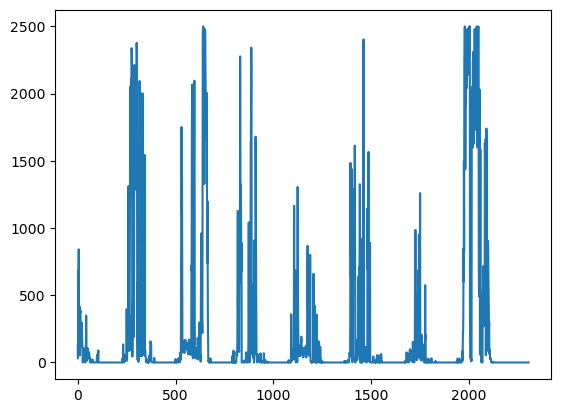

In [35]:
df['mean_lux'].plot()